# Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

# Coeficiente de correlación de Pearson
from scipy.stats import pearsonr

# Utilidades y manejo de archivos
import glob
import os

# Autorización para que GoogleColab acceda a Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Funcion Exploracion Inicial

In [ ]:
# Funcion para un Análisis Exploratorio inicial de los datos
def exploracion_inicial(df, tipo=None):
    print("¿Cuántas filas y columnas hay en el conjunto de datos?")
    num_filas, num_columnas = df.shape
    print(f"\tHay {num_filas:,} filas y {num_columnas:,} columnas.")
    print('#' * 90)

    if tipo == 'simple':
        print("¿Cuáles son las primeras dos filas del conjunto de datos?")
        display(df.head(2))
    else:
        print("¿Cuáles son las primeras cinco filas del conjunto de datos?")
        display(df.head())

        print("¿Cuáles son las últimas cinco filas del conjunto de datos?")
        display(df.tail())

        print("¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?")
        display(df.sample(n=5))

        print("¿Cuáles son las columnas del conjunto de datos?")
        print("\n".join(f"\t- {col}" for col in df.columns))

        print("¿Cuál es el tipo de datos de cada columna?")
        print(df.dtypes)

        print("¿Cuántas columnas hay de cada tipo de datos?")
        print(df.dtypes.value_counts())

        print("¿Cómo podríamos obtener información más completa sobre la estructura y el contenido del DataFrame?")
        df.info()

        print("¿Cuántos valores únicos tiene cada columna?")
        print(df.nunique())

        print("¿Cuáles son las estadísticas descriptivas básicas de todas las columnas?")
        display(df.describe(include='all').fillna(''))

        print("¿Hay valores nulos en el conjunto de datos?")
        print(df.isnull().sum())

        print("¿Cuál es la proporción de valores nulos en cada columna?")
        print((df.isnull().sum() / len(df) * 100).round(2))

    print('#' * 90)

### Carga de Datos

In [34]:
# Carga de Datos
df_orders= pd.read_csv("/content/olist_orders_datasets_clean V2 (1).csv")
df_reviews = pd.read_csv("/content/olist_reviews_dataset_clean V2 (1).csv")
df_order_items = pd.read_csv("/content/df_items_limpio.csv")
df_products = pd.read_csv("/content/olist_products_dataset_clean V2 (1).csv")
df_products_eng = pd.read_csv("/content/product_category_name_translation.csv")
df_customers = pd.read_csv("/content/olist_customers_dataset.csv")
df_sellers = pd.read_csv("/content/olist_sellers_dataset_clean V2 (1).csv")

FileNotFoundError: [Errno 2] No such file or directory: '/content/olist_orders_datasets_clean V2 (1).csv'

# Hipótesis 1 - Los estados con más demoras podrían necesitar más vendedores o mejoras logísticas

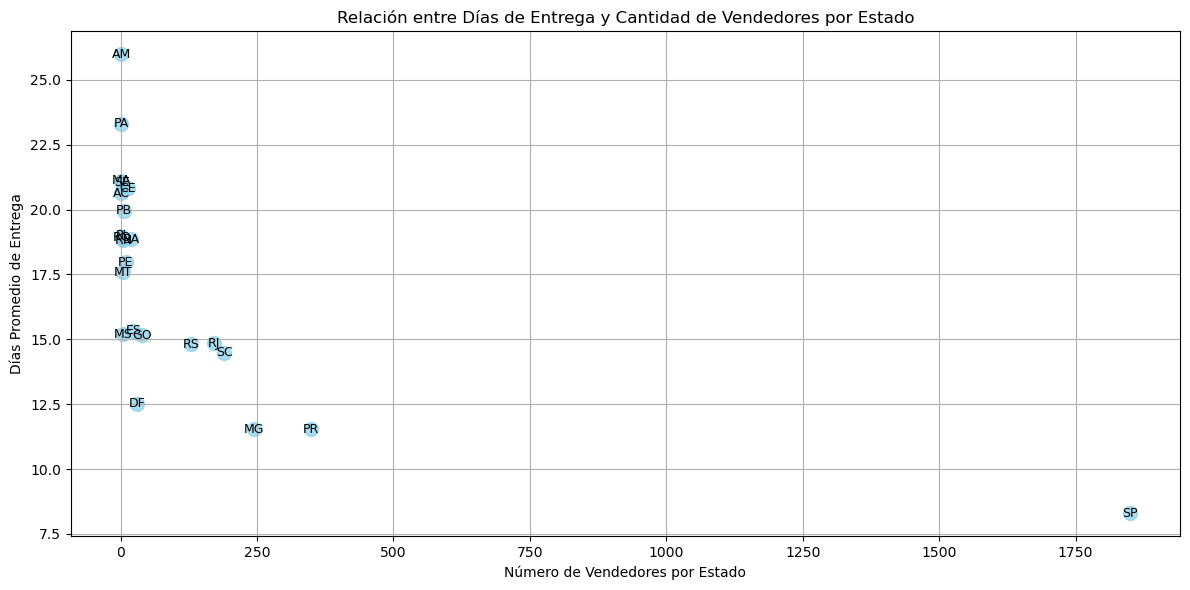

In [ ]:
# Calculamos los días de entrega
df_orders["delivery_days"] = (df_orders["order_delivered_customer_date"] - df_orders["order_purchase_timestamp"]).dt.days

# Merge de Orders con Customers
df_orders_customers = df_orders.merge(df_customers, on="customer_id")
delivery_by_state = (
    df_orders_customers.dropna(subset=["delivery_days"])
    .groupby("customer_state")["delivery_days"]
    .mean()
    .reset_index()
)


# Suponemos que un vendedor puede atender múltiples pedidos, así que tomamos su ubicación única
sellers_state = df_sellers[["seller_id", "seller_state"]].drop_duplicates()

# Contamos el número vendedores por estado
sellers_by_state = sellers_state.groupby("seller_state")["seller_id"].nunique().reset_index()
sellers_by_state.columns = ["customer_state", "num_sellers"]

# Merge de Delivery_by_State y Sellers_by_State
state_analysis = delivery_by_state.merge(sellers_by_state, on="customer_state", how="left")

# Ordenamos por días de entrega
state_analysis = state_analysis.sort_values("delivery_days", ascending=False)


# Promedio de entrega por estado
delivery_by_state = (
    df_orders_customers.dropna(subset=["delivery_days"])
    .groupby("customer_state")["delivery_days"]
    .mean()
    .reset_index()
)

# Vendedores únicos por estado
sellers_by_state = (
    df_sellers[["seller_id", "seller_state"]]
    .drop_duplicates()
    .groupby("seller_state")["seller_id"]
    .nunique()
    .reset_index()
    .rename(columns={"seller_state": "customer_state", "seller_id": "num_sellers"})
)

# Unir datos
state_analysis = delivery_by_state.merge(sellers_by_state, on="customer_state", how="left")

# Graficar
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=state_analysis,
    x="num_sellers",
    y="delivery_days",
    size="delivery_days",
    hue="delivery_days",
    palette="YlOrRd",
    legend=False,
    sizes=(50, 400)
)

for i, row in state_analysis.iterrows():
    if pd.notnull(row["num_sellers"]) and pd.notnull(row["delivery_days"]):
        plt.text(row["num_sellers"], row["delivery_days"], row["customer_state"],
                 fontsize=9, ha='center', va='center')

plt.xscale("log")
plt.xlabel("Número de Vendedores por Estado")
plt.ylabel("Días Promedio de Entrega")
plt.title("Relación entre Vendedores Vs Tiempo de Entrega")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


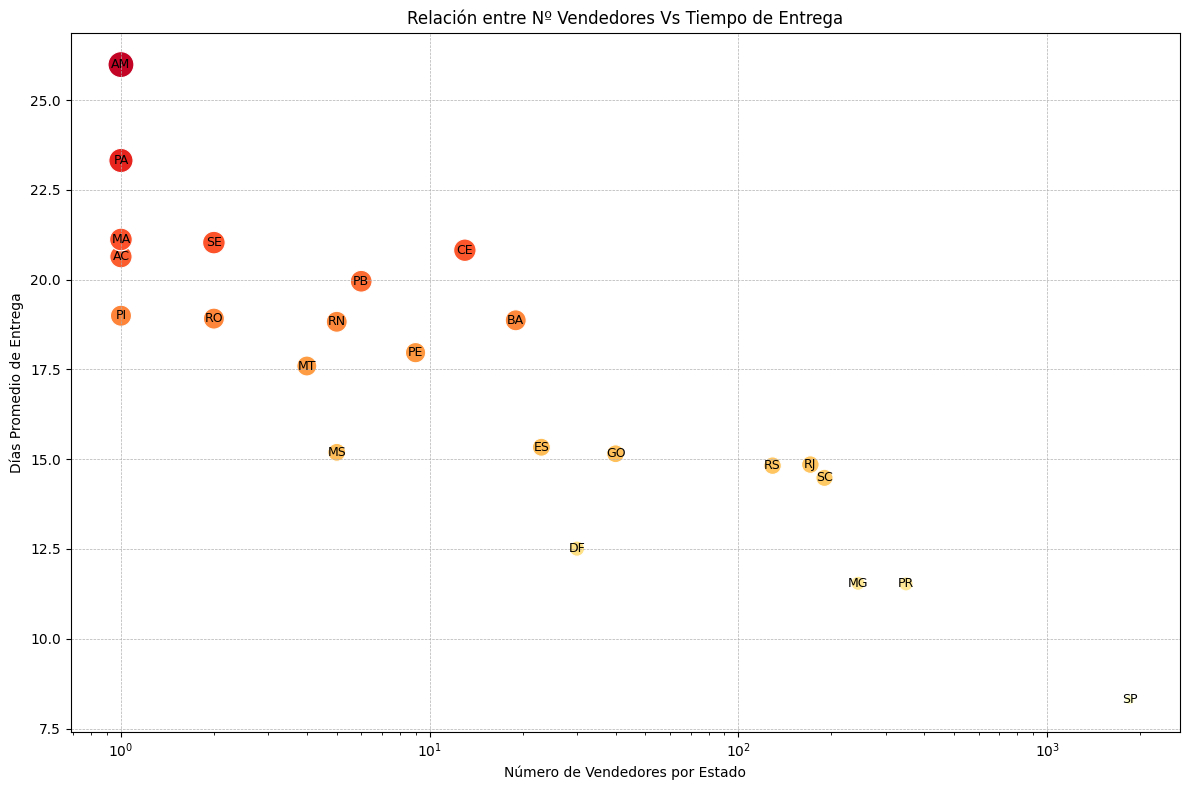

# Hipótesis 2 - Los costos de envío aumentan por peso y distancia.

El objetivo es analizar el impacto de los costos de envío sobre las ventas totales, con el objetivo de confirmar su relación con la distancia y el peso facturable. A partir de este análisis, se busca identificar oportunidades para optimizar dichos costos y aprovechar posibles sinergias logísticas que mejoren la eficiencia operativa

El análisis se centrará en las ordenes con status "delivered" (entregadas)

## Carga de datos

Utilizaremos el **dataset 1_df_merge.csv** ya que cuenta con información que nos permitirá hacer análisis cruzados

In [2]:
df_merge = pd.read_csv("/content/drive/MyDrive/nuclio/TFM NUCLIO/TFM Olist Ecommerce FINAL/03. Datasets Merged/1_df_merge.csv")

/tmp/ipython-input-2-4213026401.py:1: DtypeWarning: Columns (33,34) have mixed types. Specify dtype option on import or set low_memory=False.
  df_merge = pd.read_csv("/content/drive/MyDrive/nuclio/TFM NUCLIO/TFM Olist Ecommerce FINAL/03. Datasets Merged/1_df_merge.csv")


## Exploración de datos

In [ ]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102425 entries, 0 to 102424
Data columns (total 50 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   order_id                           102425 non-null  object 
 1   ord_customer_id                    102425 non-null  object 
 2   ord_order_status                   102425 non-null  object 
 3   ord_order_purchase_timestamp       102425 non-null  object 
 4   ord_order_approved_at              102411 non-null  object 
 5   ord_order_delivered_carrier_date   101397 non-null  object 
 6   ord_order_delivered_customer_date  100195 non-null  object 
 7   ord_order_estimated_delivery_date  102425 non-null  object 
 8   ord_purchase_to_approval_days      102411 non-null  float64
 9   ord_approval_to_carrier_days       101383 non-null  float64
 10  ord_carrier_to_customer_days       100194 non-null  float64
 11  ord_purchase_to_delivery_days      1001

Conversión de las columnas en fecha

In [3]:
# Convertir columnas de fechas al tipo datetime
fecha_columnas = [
    'ord_order_purchase_timestamp',
    'ord_order_approved_at',
    'ord_order_delivered_carrier_date',
    'ord_order_delivered_customer_date',
    'ord_order_estimated_delivery_date'
]

# Aplicar la conversión
df_merge[fecha_columnas] = df_merge[fecha_columnas].apply(pd.to_datetime, errors='coerce')

# Verificar los tipos de datos después de la conversión
df_merge[fecha_columnas].dtypes


,0
ord_order_purchase_timestamp,datetime64[ns]
ord_order_approved_at,datetime64[ns]
ord_order_delivered_carrier_date,datetime64[ns]
ord_order_delivered_customer_date,datetime64[ns]
ord_order_estimated_delivery_date,datetime64[ns]


## Dataframe ordenes "delivered", ventas y costos de envío

In [4]:
delivered_df = df_merge[df_merge['ord_order_status'] == 'delivered'].copy()
total_ventas_entregados = delivered_df['total'].sum()
total_costos_envio_entregados = delivered_df['freight_value_total'].sum()
proporcion_envio_entregados = total_costos_envio_entregados / total_ventas_entregados

print("\nSolo pedidos entregados:")
print(f"Total de ventas (entregados): R$ {total_ventas_entregados:,.2f}")
print(f"Total de costos de envío (entregados): R$ {total_costos_envio_entregados:,.2f}")
print(f"Proporción del costo de envío sobre ventas (entregados): {proporcion_envio_entregados:.2%}")


Solo pedidos entregados:
Total de ventas (entregados): R$ 15,419,773.75
Total de costos de envío (entregados): R$ 2,198,275.64
Proporción del costo de envío sobre ventas (entregados): 14.26%


## Evolución mensual

Evolución mensual de las ventas totales y los costos totales de envío de ordenes con status **delivered**

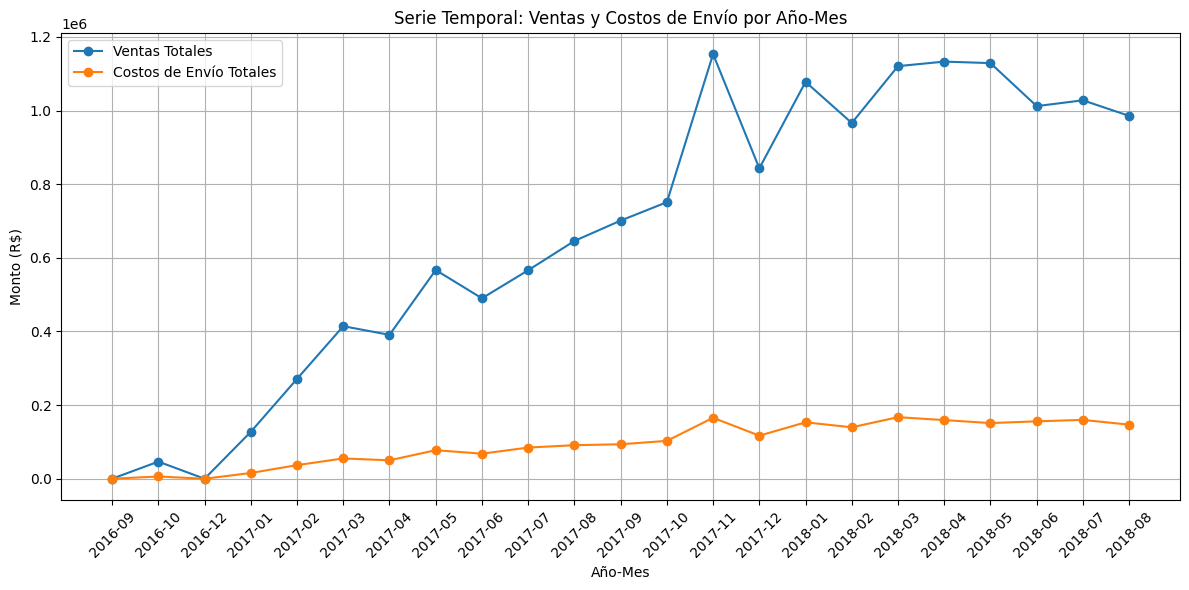

In [5]:
# Filtrar solo pedidos entregados
# delivered_df = df_merge[df_merge['ord_order_status'] == 'delivered'].copy()

# Crear columna de año-mes
delivered_df['anio_mes'] = delivered_df['ord_order_purchase_timestamp'].dt.to_period('M').astype(str)

# Agrupar por año-mes y sumar ventas y costos de envío
serie_tiempo = delivered_df.groupby('anio_mes')[['total', 'freight_value_total']].sum().reset_index()

# Graficar la serie temporal
plt.figure(figsize=(12, 6))
plt.plot(serie_tiempo['anio_mes'], serie_tiempo['total'], marker='o', label='Ventas Totales')
plt.plot(serie_tiempo['anio_mes'], serie_tiempo['freight_value_total'], marker='o', label='Costos de Envío Totales')
plt.xticks(rotation=45)
plt.xlabel('Año-Mes')
plt.ylabel('Monto (R$)')
plt.title('Serie Temporal: Ventas y Costos de Envío por Año-Mes')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Se puede observar que ambas series siguen la misma tendencia reflejando un crecimiento en ventas y costos de envío.

Sin embargo, a lo largo del periodo la brecha entre ventas y costos de envío tiende a ampliarse, lo que podría sugerir una mejora relativa en la eficiencia logística.  Aparentemente los costos de envío representan una proporción menor del total vendido.  

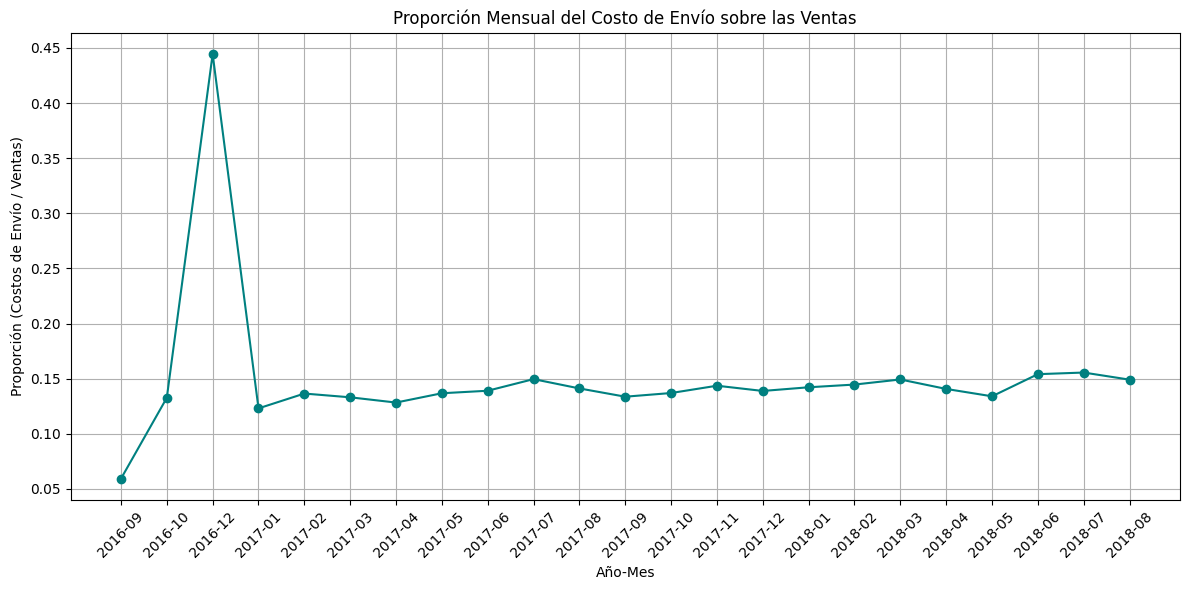

In [6]:
# Calcular la proporción mensual
serie_tiempo['proporcion_envio'] = serie_tiempo['freight_value_total'] / serie_tiempo['total']

# Graficar la proporción mensual
plt.figure(figsize=(12, 6))
plt.plot(serie_tiempo['anio_mes'], serie_tiempo['proporcion_envio'], marker='o', color='teal')
plt.xticks(rotation=45)
plt.xlabel('Año-Mes')
plt.ylabel('Proporción (Costos de Envío / Ventas)')
plt.title('Proporción Mensual del Costo de Envío sobre las Ventas')
plt.grid(True)
plt.tight_layout()
plt.show()

Como se muestra en la siguiente tabla, los datos correspondientes a diciembre de 2016 presentan una desproporción significativa debido a que solo se registró una única venta. En este caso, los costos de envío representaron un valor casi equivalente al monto total de la venta, lo que distorsiona la proporción habitual observada en otros períodos.

In [7]:
# Filtrar datos del mes 2016-12 y pedidos entregados
df_2016_12 = delivered_df[delivered_df['anio_mes'] == '2016-12']

# Agrupar por categoría de producto
ventas_2016_12 = (
    df_2016_12.groupby('pro_product_category_name_english')
    .agg(
        total_ordenes=('order_id', 'nunique'),
        ventas_totales=('total', 'sum'),
        costos_envio=('freight_value_total', 'sum')
    )
    .sort_values(by='ventas_totales', ascending=False)
)

display(df_2016_12)

,order_id,ord_customer_id,ord_order_status,ord_order_purchase_timestamp,ord_order_approved_at,ord_order_delivered_carrier_date,ord_order_delivered_customer_date,ord_order_estimated_delivery_date,ord_purchase_to_approval_days,ord_approval_to_carrier_days,...,geo_state_cust,geo_Estado_cust,geo_lat_sell,geo_lng_sell,geo_state_sell,geo_Estado_sell,distancia_km,estado_origen,estado_destino,anio_mes
40947,bd50a7fe9fd97ea4b7663031a319e150,0975c3cf2e418ebfa5d1191a2dffd59d,delivered,2016-12-23 23:16:47,2016-12-23 23:31:37,2016-12-27 06:14:27,2016-12-28 15:54:44,2017-01-19,0.0,3.0,...,PR,Paraná,-25.503903,-49.29915,PR,Paraná,10.431613,PR_S,PR_C,2016-12


## Evolución Diaria y Mensual

Para facilitar la interpretación visual, se utilizará un heatmap que muestre el total de ventas y los costos de envío distribuidos por mes y día.

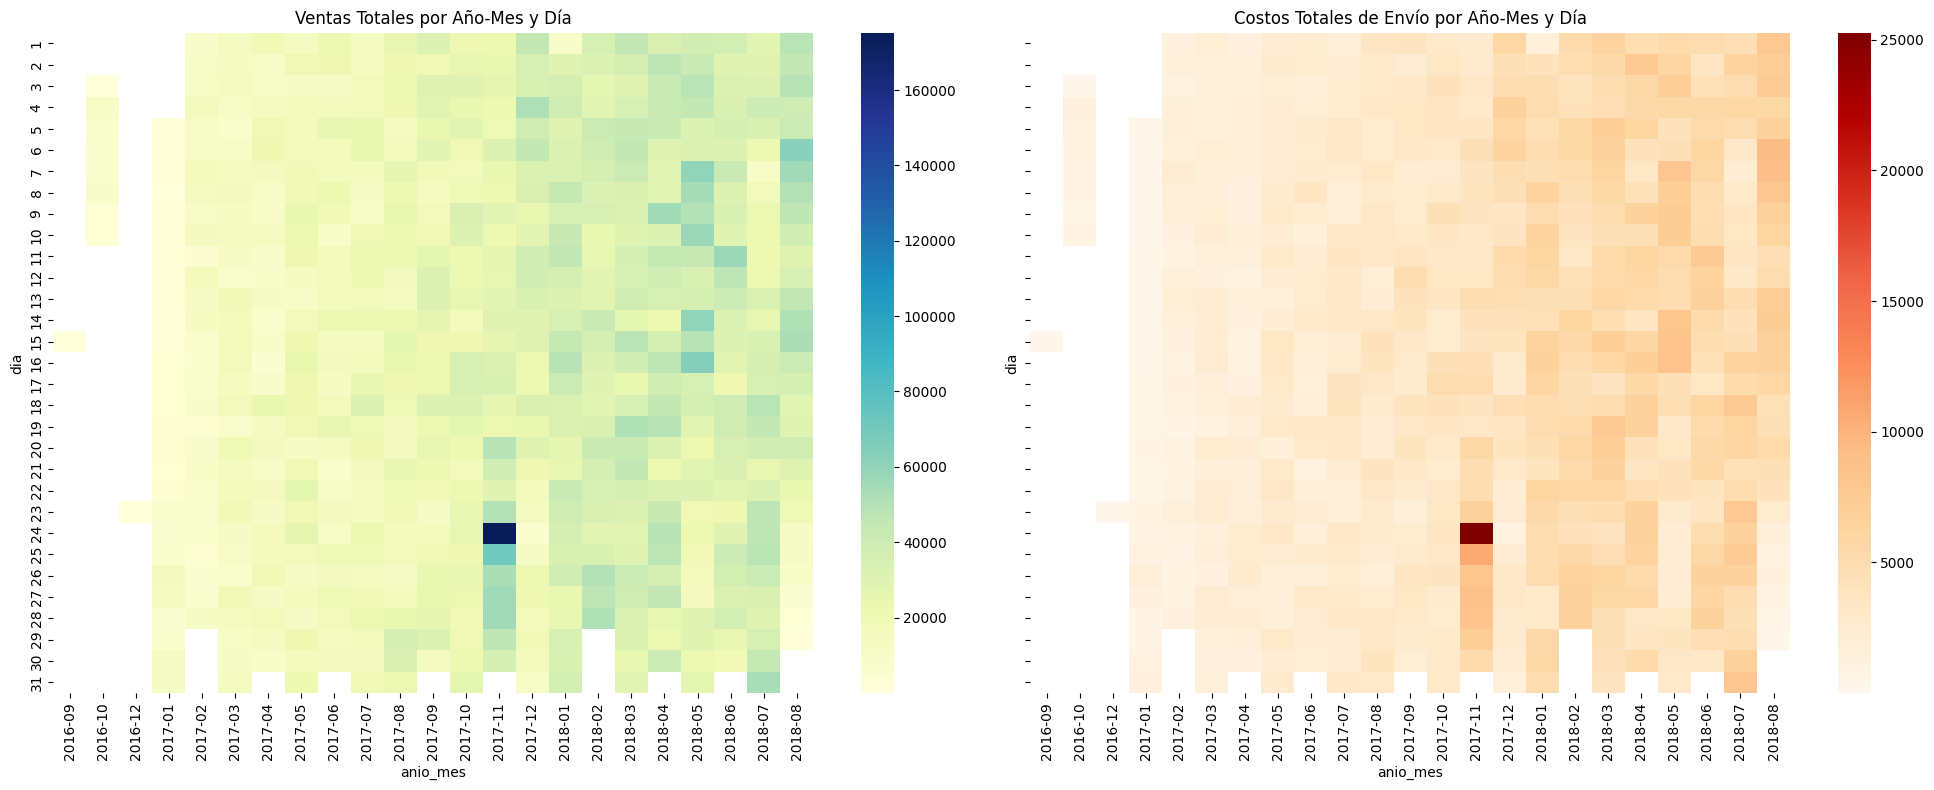

In [8]:
# Extraer año-mes y día del mes
delivered_df['anio_mes'] = delivered_df['ord_order_purchase_timestamp'].dt.to_period('M').astype(str)
delivered_df['dia'] = delivered_df['ord_order_purchase_timestamp'].dt.day

# Crear tablas dinámicas (pivot tables) para ventas totales y costos de envío totales
ventas_pivot = delivered_df.pivot_table(index='dia', columns='anio_mes', values='total', aggfunc='sum')
envio_pivot = delivered_df.pivot_table(index='dia', columns='anio_mes', values='freight_value_total', aggfunc='sum')

# Graficar los heatmaps
fig, axs = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

sns.heatmap(ventas_pivot, cmap='YlGnBu', ax=axs[0])
axs[0].set_title('Ventas Totales por Año-Mes y Día')

sns.heatmap(envio_pivot, cmap='OrRd', ax=axs[1])
axs[1].set_title('Costos Totales de Envío por Año-Mes y Día')

plt.tight_layout()
plt.show()


En ambos gráficos se constata que, por mes y día, hay una relación entre las ventas y los costos de envío.  

**Se confirma que en el 24.11 (Black Friday) hubo un pico en las ventas y en los costos de envío**

## Proporción mensual de costo de envío sobre ventas e individual sobre el total  

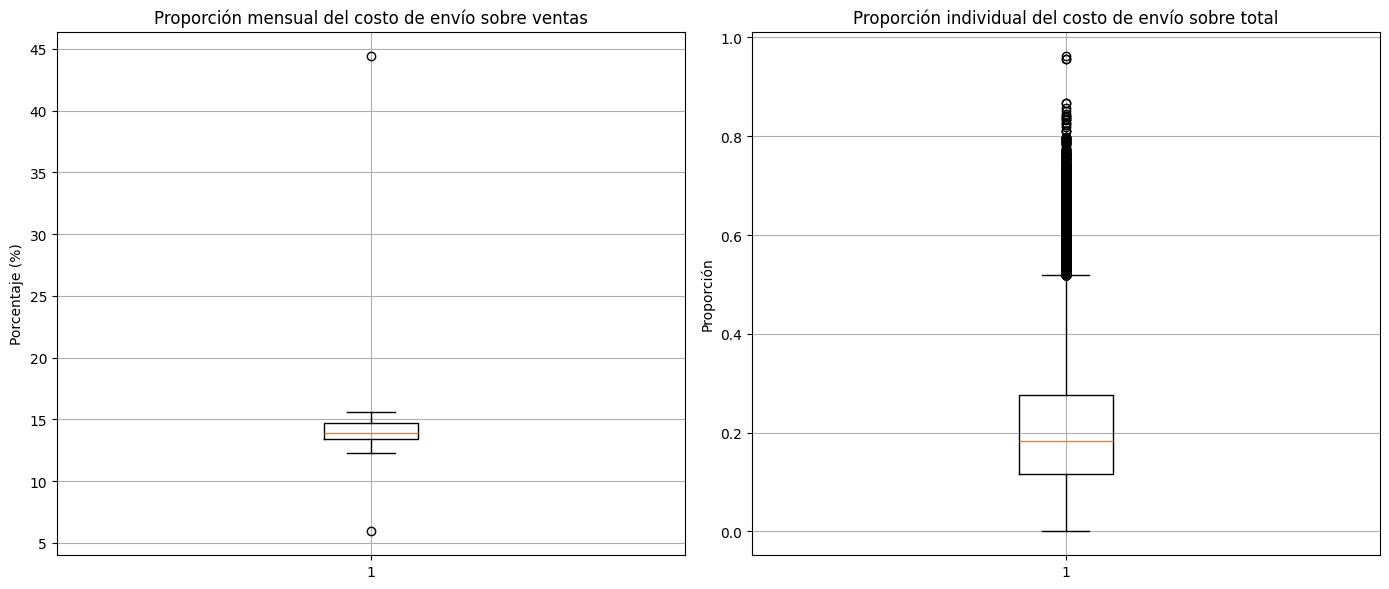

In [9]:
# Filtrar pedidos entregados
# delivered_df = df_merge[df_merge['ord_order_status'] == 'delivered'].copy()

# --- Boxplot por mes ---
# Crear columna de año-mes
delivered_df['anio_mes'] = delivered_df['ord_order_purchase_timestamp'].dt.to_period('M').astype(str)

# Agrupar por año-mes y sumar ventas y costos de envío
serie_tiempo = delivered_df.groupby('anio_mes')[['total', 'freight_value_total']].sum().reset_index()
# Calcular el peso porcentual mensual
serie_tiempo['peso_envio_sobre_ventas'] = (serie_tiempo['freight_value_total'] / serie_tiempo['total']) * 100

# --- Boxplot por orden individual ---
# Calcular proporción por pedido
delivered_df['shipping_cost_weight'] = delivered_df['freight_value_total'] / delivered_df['total']

# --- Graficar ambos ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Por mes
axes[0].boxplot(serie_tiempo['peso_envio_sobre_ventas'].dropna(), vert=True)
axes[0].set_title('Proporción mensual del costo de envío sobre ventas')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].grid(True)

# Gráfico 2: Por orden
axes[1].boxplot(delivered_df['shipping_cost_weight'].dropna(), vert=True)
axes[1].set_title('Proporción individual del costo de envío sobre total')
axes[1].set_ylabel('Proporción')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Estos gráficos nos ayudan a entender el peso que tienen los costos de envío tanto a nivel mensual (izquierda) como a nivel individual (derecha).


* **Proporción mensual del costo de envío sobre ventas**

El gráfico de la izquierda muestra un boxplot que representa la distribución de la proporción entre el costo total de envío y las ventas totales para cada mes (23 valores en total, uno por mes). Es decir, para cada mes, se calcula el porcentaje que representa el costo de envío respecto al total de ventas de ese mes.


* **Proporción individual del costo de envío sobre el total**

El gráfico de la derecha presenta un boxplot de la proporción entre el costo de envío y el monto total pagado por cada pedido, considerando únicamente los pedidos entregados. Aquí, cada punto representa un pedido individual y su respectiva proporción.


Como puede observarse, especialmente en el gráfico de la derecha, existen numerosos valores atípicos (outliers), lo que podría afectar la interpretación de los análisis posteriores. Por ello, vamos a proceder a eliminarlos para asegurar que nuestras conclusiones se basen en distribuciones más representativas.

## Proporción mensual de costo de envío sobre ventas e individual sobre el total (SIN OUTLIERS)

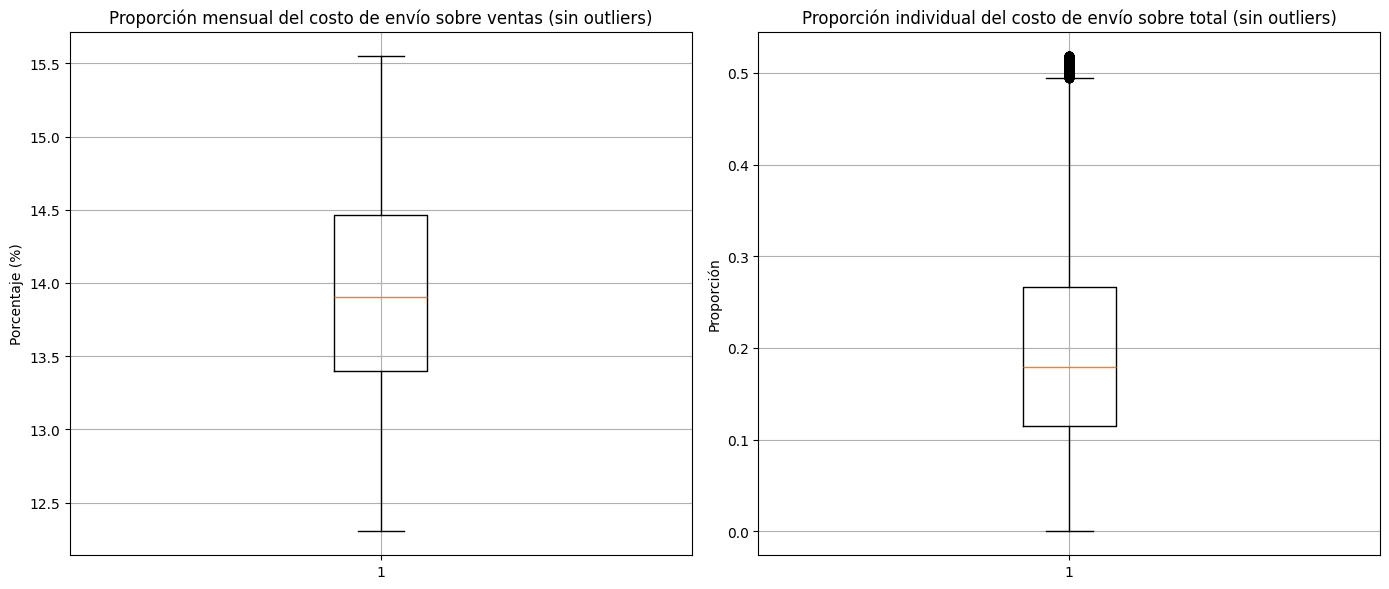

In [10]:
# --- Función para quitar outliers con IQR ---
def remove_outliers_iqr(data, coef=1.5):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower = q1 - coef * iqr
    upper = q3 + coef * iqr
    return data[(data >= lower) & (data <= upper)]

# 1. Filtrar pedidos entregados
delivered_df = df_merge[df_merge['ord_order_status'] == 'delivered'].copy()

# 2. Columna año-mes y proporciones mensuales
delivered_df['anio_mes'] = delivered_df['ord_order_purchase_timestamp'].dt.to_period('M').astype(str)
serie_tiempo = delivered_df.groupby('anio_mes')[['total', 'freight_value_total']].sum().reset_index()
serie_tiempo['peso_envio_sobre_ventas'] = (serie_tiempo['freight_value_total'] / serie_tiempo['total']) * 100

# 3. Proporción por pedido
delivered_df['shipping_cost_weight'] = delivered_df['freight_value_total'] / delivered_df['total']

# 4. Eliminar outliers de cada serie
serie_mensual_filtrada = remove_outliers_iqr(serie_tiempo['peso_envio_sobre_ventas'].dropna())
shipping_cost_weight_filtrada = remove_outliers_iqr(delivered_df['shipping_cost_weight'].dropna())

# 5. Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot mensual sin outliers
axes[0].boxplot(serie_mensual_filtrada, vert=True)
axes[0].set_title('Proporción mensual del costo de envío sobre ventas (sin outliers)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].grid(True)

# Boxplot individual sin outliers
axes[1].boxplot(shipping_cost_weight_filtrada, vert=True)
axes[1].set_title('Proporción individual del costo de envío sobre total (sin outliers)')
axes[1].set_ylabel('Proporción')
axes[1].grid(True)

plt.tight_layout()
plt.show()


## Impacto de quitar los outliers del análisis

In [11]:
# --- Función para quitar outliers con IQR ---
def remove_outliers_iqr_series(data, coef=1.5):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower = q1 - coef * iqr
    upper = q3 + coef * iqr
    return (data >= lower) & (data <= upper)

# 1. Filtrar pedidos entregados
delivered_df = df_merge[df_merge['ord_order_status'] == 'delivered'].copy()

# 2. Calcular proporción por pedido
delivered_df['shipping_cost_weight'] = delivered_df['freight_value_total'] / delivered_df['total']

# 3. Calcular métricas con datos originales
ventas_originales = delivered_df['total'].sum()
envio_originales = delivered_df['freight_value_total'].sum()
proporcion_original = (envio_originales / ventas_originales) * 100

# 4. Quitar outliers de la proporción
mask = remove_outliers_iqr_series(delivered_df['shipping_cost_weight'].dropna())
filtered_df = delivered_df.loc[delivered_df['shipping_cost_weight'].dropna().index[mask]]

# 5. Calcular métricas sin outliers
ventas_filtradas = filtered_df['total'].sum()
envio_filtrados = filtered_df['freight_value_total'].sum()
proporcion_filtrada = (envio_filtrados / ventas_filtradas) * 100

# 6. Calcular diferencias
diferencia_ventas = ((ventas_filtradas - ventas_originales) / ventas_originales) * 100
diferencia_envio = ((envio_filtrados - envio_originales) / envio_originales) * 100
diferencia_proporcion = proporcion_filtrada - proporcion_original

# 7. Crear tabla comparativa
tabla_comparativa = pd.DataFrame({
    'Métrica': ['Ventas totales (R$)', 'Costos de envío (R$)', 'Proporción envío/ventas (%)'],
    'Original': [ventas_originales, envio_originales, round(proporcion_original, 2)],
    'Sin Outliers': [ventas_filtradas, envio_filtrados, round(proporcion_filtrada, 2)],
    'Diferencia (%)': [round(diferencia_ventas, 2), round(diferencia_envio, 2), round(diferencia_proporcion, 2)]
})

tabla_comparativa


,Métrica,Original,Sin Outliers,Diferencia (%)
0,Ventas totales (R$),15419773.75,15285168.32,-0.87
1,Costos de envío (R$),2198275.64,2117894.23,-3.66
2,Proporción envío/ventas (%),14.26,13.86,-0.40


Se observa que la eliminación de outliers no impacta significativamente los resultados del análisis. Por tanto, su exclusión no representa un riesgo de sesgo y permite trabajar con una representación más robusta y depurada de los datos.

## Factores que influyen en el costo de envío

Los costos de envío pueden depender de varios factores. En el contexto que estamos análizando, estos costos pueden estar influenciados por:

* Distancia entre vendedor y cliente
* Peso facturable. Es el peso que se usa para calcular el costo del envío y es el mayor entre el peso real y el peso volumétrico.

    * Peso real (gross) es el peso físico del producto
    * Peso volumétrico (o dimensional) Correios en Brasil (principal empresa de logística) utiliza la siguiente fórmula (Largo x Ancho x Alto) / 6.000. Las dimensiones tienen que estar expresadas en centimetros y el resultado se expresa en kilogramos.

* Cantidad de ítems en el pedido


### 1 Costo de envío vs peso facturable

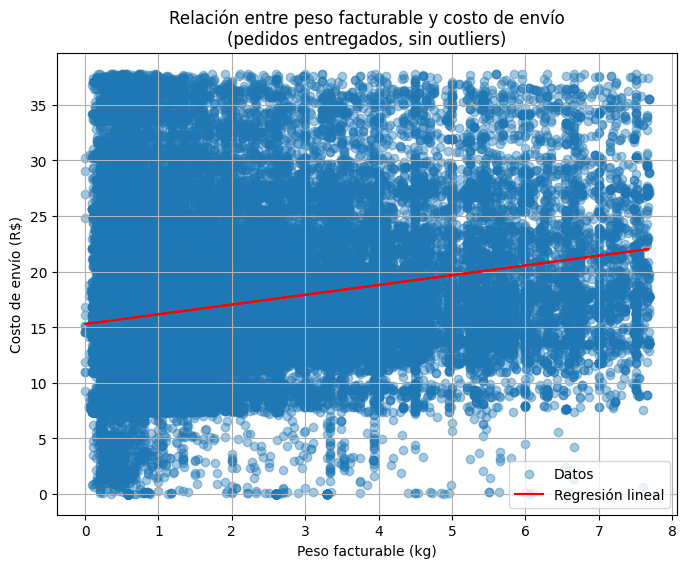

Correlación entre peso facturable y costo de envío: 0.23
Valor p: 0.0000
Regresión lineal: y = 0.88x + 15.27


In [12]:
# Filtrar solo pedidos entregados
delivered_df = df_merge[df_merge['ord_order_status'] == 'delivered'].copy()

# Quitar outliers de peso facturable
peso_sin_outliers = remove_outliers_iqr(delivered_df['pro_peso_facturable_kg'].dropna())

# Quitar outliers de costo de envío
envio_sin_outliers = remove_outliers_iqr(delivered_df['freight_value_total'].dropna())

# Mantener solo pedidos que no son outliers en ambas variables
filtro = delivered_df['pro_peso_facturable_kg'].isin(peso_sin_outliers) & \
         delivered_df['freight_value_total'].isin(envio_sin_outliers)
df_sin_outliers = delivered_df[filtro]

# Variables
x = df_sin_outliers['pro_peso_facturable_kg']
y = df_sin_outliers['freight_value_total']

# Calcular correlación y valor p
r, p_value = pearsonr(x, y)

# Ajuste de regresión lineal
coef = np.polyfit(x, y, 1)
y_fit = np.poly1d(coef)(x)

# Gráfico con línea de regresión
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.4, label='Datos')
plt.plot(x, y_fit, color='red', label='Regresión lineal')
plt.xlabel('Peso facturable (kg)')
plt.ylabel('Costo de envío (R$)')
plt.title('Relación entre peso facturable y costo de envío\n(pedidos entregados, sin outliers)')
plt.grid(True)
plt.legend()
plt.show()

# Resultados en consola
print(f"Correlación entre peso facturable y costo de envío: {r:.2f}")
print(f"Valor p: {p_value:.4f}")
print(f"Regresión lineal: y = {coef[0]:.2f}x + {coef[1]:.2f}")




El valor 0.23 nos indica una correlación positiva débil.

La línea de regresión asciende suamente, lo que indica que a mayor peso facturable, mayor costo de envío, pero el efecto es muy moderado.

**La relación entre peso facturable y costo de envío existe, pero es débil**

**Hay mucha variabilidad en el costo de envío incluso para un mismo peso.  Esto sugiere que no es el único ni el pricipal factor para determinar el costo de envío**

El valor p=0.0000 nos indica que la relación encontrada no es por azar

### Concentración de pedidos - Mapa de densidad

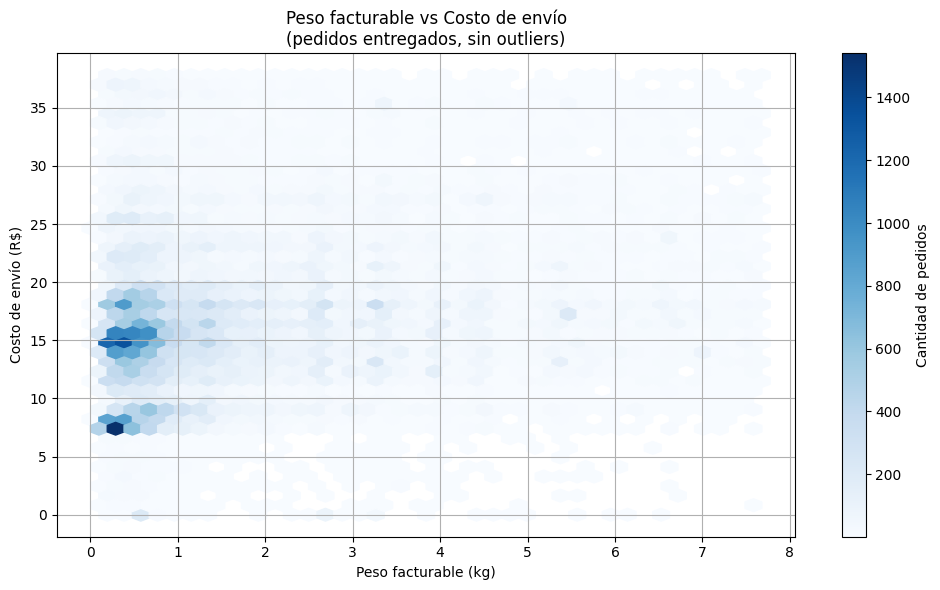

Correlación entre peso facturable y costo de envío: 0.23
Valor p: 0.0000


In [13]:
# Filtrar solo pedidos entregados
delivered_df = df_merge[df_merge['ord_order_status'] == 'delivered'].copy()

# Quitar outliers de peso facturable
peso_sin_outliers = remove_outliers_iqr(delivered_df['pro_peso_facturable_kg'].dropna())

# Quitar outliers de costo de envío
envio_sin_outliers = remove_outliers_iqr(delivered_df['freight_value_total'].dropna())

# Mantener solo pedidos que no son outliers en ambas variables
filtro = delivered_df['pro_peso_facturable_kg'].isin(peso_sin_outliers) & \
         delivered_df['freight_value_total'].isin(envio_sin_outliers)
df_sin_outliers = delivered_df[filtro]

# Calcular correlación y valor p
x = df_sin_outliers['pro_peso_facturable_kg']
y = df_sin_outliers['freight_value_total']
r, p_value = pearsonr(x, y)

# Gráfico de densidad 2D
plt.figure(figsize=(10, 6))
hb = plt.hexbin(
    x,
    y,
    gridsize=40,
    cmap='Blues',
    mincnt=1
)
cb = plt.colorbar(hb)
cb.set_label('Cantidad de pedidos')

plt.xlabel('Peso facturable (kg)')
plt.ylabel('Costo de envío (R$)')
plt.title('Peso facturable vs Costo de envío\n(pedidos entregados, sin outliers)')
plt.grid(True)
plt.tight_layout()
plt.show()



# Imprimir resultados estadísticos
print(f"Correlación entre peso facturable y costo de envío: {r:.2f}")
print(f"Valor p: {p_value:.4f}")


En este gráfico se observa más claramente, por densidad, la cantidad de pedidos involucrados, el peso facturable y el costo de envío.  

**Hay que considerar otros factores para explicar mejor el costo de envío.**

### Costo promedio por rango de peso facturable

/tmp/ipython-input-14-4256194505.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grupo_peso = df_sin_outliers.groupby('peso_rango')['freight_value_total'].mean().reset_index()


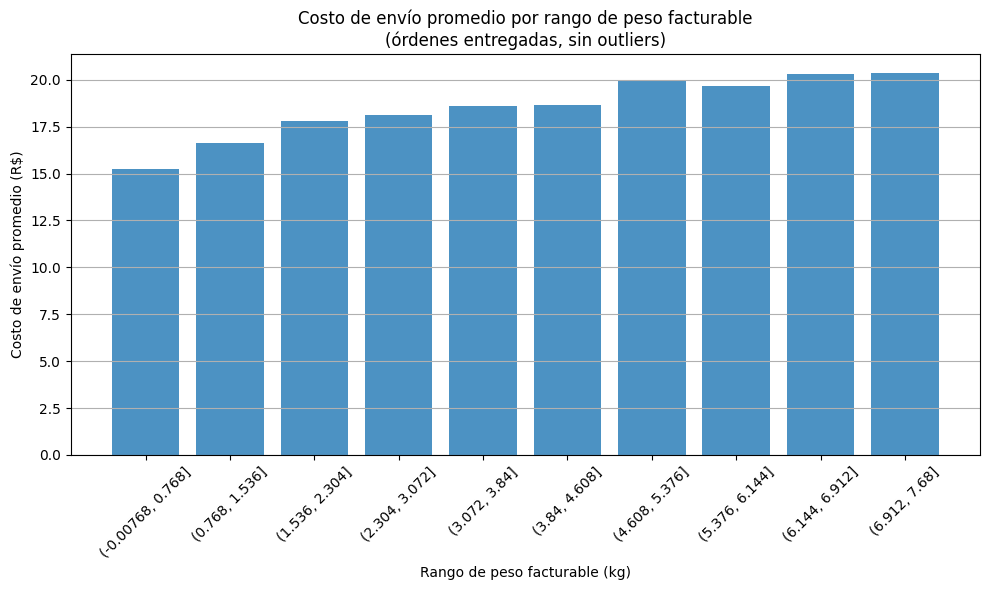

In [14]:
# 1. Filtrar pedidos entregados
delivered_df = df_merge[df_merge['ord_order_status'] == 'delivered'].copy()

# 2. Quitar outliers de peso facturable y costo de envío
peso_sin_outliers = remove_outliers_iqr(delivered_df['pro_peso_facturable_kg'].dropna())
envio_sin_outliers = remove_outliers_iqr(delivered_df['freight_value_total'].dropna())

# 3. Mantener solo pedidos válidos
filtro = delivered_df['pro_peso_facturable_kg'].isin(peso_sin_outliers) & \
         delivered_df['freight_value_total'].isin(envio_sin_outliers)
df_sin_outliers = delivered_df[filtro].copy()

# 4. Crear rangos de peso facturable
df_sin_outliers['peso_rango'] = pd.cut(df_sin_outliers['pro_peso_facturable_kg'], bins=10)

# 5. Calcular el costo de envío promedio por rango
grupo_peso = df_sin_outliers.groupby('peso_rango')['freight_value_total'].mean().reset_index()

# 6. Gráfico
plt.figure(figsize=(10, 6))
plt.bar(grupo_peso['peso_rango'].astype(str), grupo_peso['freight_value_total'], alpha=0.8)
plt.xticks(rotation=45)
plt.xlabel('Rango de peso facturable (kg)')
plt.ylabel('Costo de envío promedio (R$)')
plt.title('Costo de envío promedio por rango de peso facturable\n(órdenes entregadas, sin outliers)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()



### 2 Costo envío vs distancia

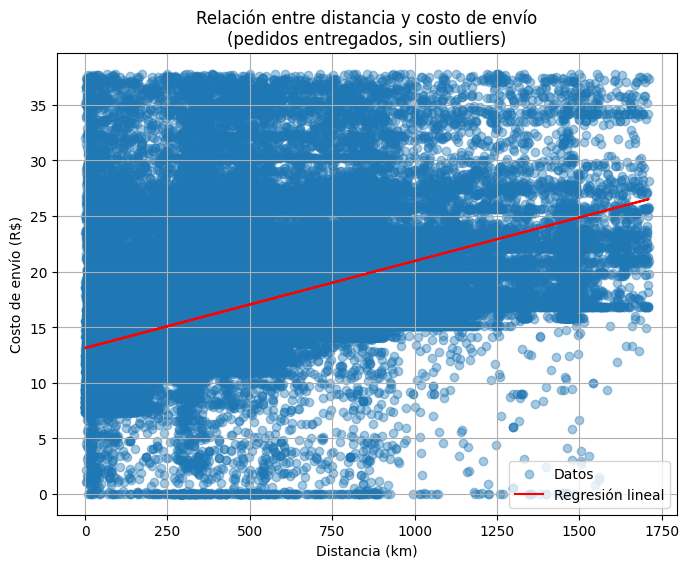

Correlación entre distancia y costo de envío: 0.44
Valor p: 0.0000
Regresión lineal: y = 0.01x + 13.12


In [15]:
# Filtrar solo pedidos entregados
delivered_df = df_merge[df_merge['ord_order_status'] == 'delivered'].copy()

# Quitar outliers de distancia
distancia_sin_outliers = remove_outliers_iqr(delivered_df['distancia_km'].dropna())

# Quitar outliers de costo de envío
envio_sin_outliers = remove_outliers_iqr(delivered_df['freight_value_total'].dropna())

# Mantener solo pedidos válidos
filtro = delivered_df['distancia_km'].isin(distancia_sin_outliers) & \
         delivered_df['freight_value_total'].isin(envio_sin_outliers)
df_sin_outliers = delivered_df[filtro]

# Variables
x = df_sin_outliers['distancia_km']
y = df_sin_outliers['freight_value_total']

# Calcular correlación y valor p
r, p_value = pearsonr(x, y)

# Ajuste de regresión lineal
coef = np.polyfit(x, y, 1)
y_fit = np.poly1d(coef)(x)

# Gráfico con línea de regresión
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.4, label='Datos')
plt.plot(x, y_fit, color='red', label='Regresión lineal')
plt.xlabel('Distancia (km)')
plt.ylabel('Costo de envío (R$)')
plt.title('Relación entre distancia y costo de envío\n(pedidos entregados, sin outliers)')
plt.grid(True)
plt.legend()
plt.show()

# Resultados en consola
print(f"Correlación entre distancia y costo de envío: {r:.2f}")
print(f"Valor p: {p_value:.4f}")
print(f"Regresión lineal: y = {coef[0]:.2f}x + {coef[1]:.2f}")



El valor 0.44 nos indica una correlación positiva débil.

La línea de regresión asciende suamente, lo que indica que a mayor distancia mayor es el costo de envío.

**La distancia sí influye en el costo de envío**

**Aunque hay una tendencia el gráfico muestra mucha variabilidad.  Para una misma distancia el costo de envío puede variar bastante lo que nos sugiere que si bien la distancia es importante no es el único factor que influye en el costo**

El valor p=0.0000 nos indica que la relación encontrada no es por azar

### Concentración de pedidos - Mapa de densidad

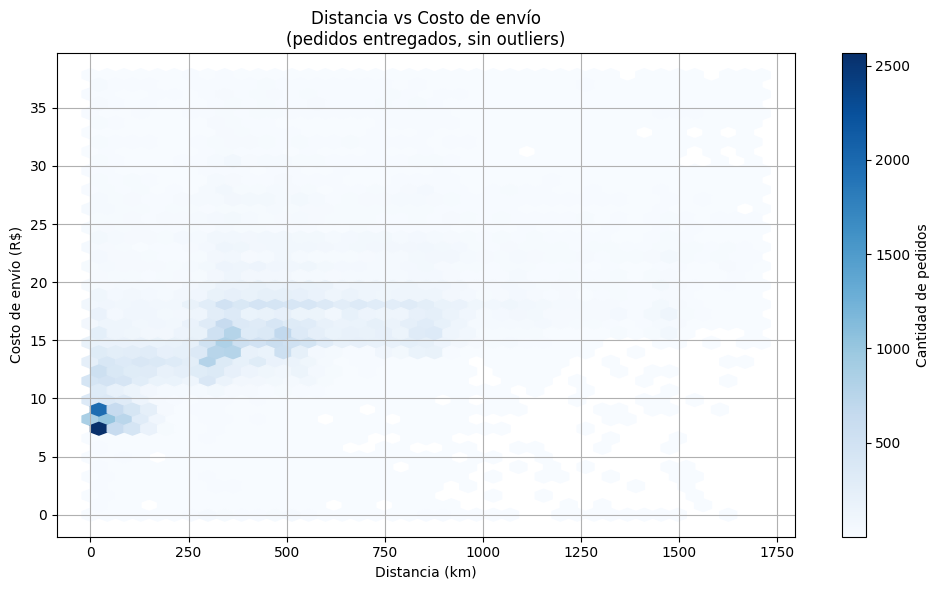

Correlación entre distancia y costo de envío: 0.44
Valor p: 0.0000


In [16]:
# Filtrar solo pedidos entregados
delivered_df = df_merge[df_merge['ord_order_status'] == 'delivered'].copy()

# Quitar outliers de distancia
distancia_sin_outliers = remove_outliers_iqr(delivered_df['distancia_km'].dropna())

# Quitar outliers de costo de envío
envio_sin_outliers = remove_outliers_iqr(delivered_df['freight_value_total'].dropna())

# Mantener solo pedidos que no son outliers en ambas variables
filtro = delivered_df['distancia_km'].isin(distancia_sin_outliers) & \
         delivered_df['freight_value_total'].isin(envio_sin_outliers)
df_sin_outliers = delivered_df[filtro]

# Calcular correlación y valor p
x = df_sin_outliers['distancia_km']
y = df_sin_outliers['freight_value_total']
r, p_value = pearsonr(x, y)

# Gráfico de densidad 2D (hexbin)
plt.figure(figsize=(10, 6))
hb = plt.hexbin(
    x,
    y,
    gridsize=40,
    cmap='Blues',
    mincnt=1
)
cb = plt.colorbar(hb)
cb.set_label('Cantidad de pedidos')

plt.xlabel('Distancia (km)')
plt.ylabel('Costo de envío (R$)')
plt.title('Distancia vs Costo de envío\n(pedidos entregados, sin outliers)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Imprimir resultados estadísticos
print(f"Correlación entre distancia y costo de envío: {r:.2f}")
print(f"Valor p: {p_value:.4f}")


Se observa que la mayor cantidad de pedidos se concentra en distancias menores a 200 km con costos de envío que oscilan entre R$8 y R$10.
A medida que la distancia aumenta (por encima de 500 km) los pedidos se dispersan y el costo tiende a subir .

Hay una tendencia general de que a mayor distancia, el costo de envío es mayor, pero con mucha variación.

El gráfico refuerza que la distancia inflye en el costo de envío, pero no determina por lo determina por completo

### Costo promedio por rango de distancia

/tmp/ipython-input-17-4215333265.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grupo_distancia = df_sin_outliers.groupby('distancia_rango')['freight_value_total'].mean().reset_index()


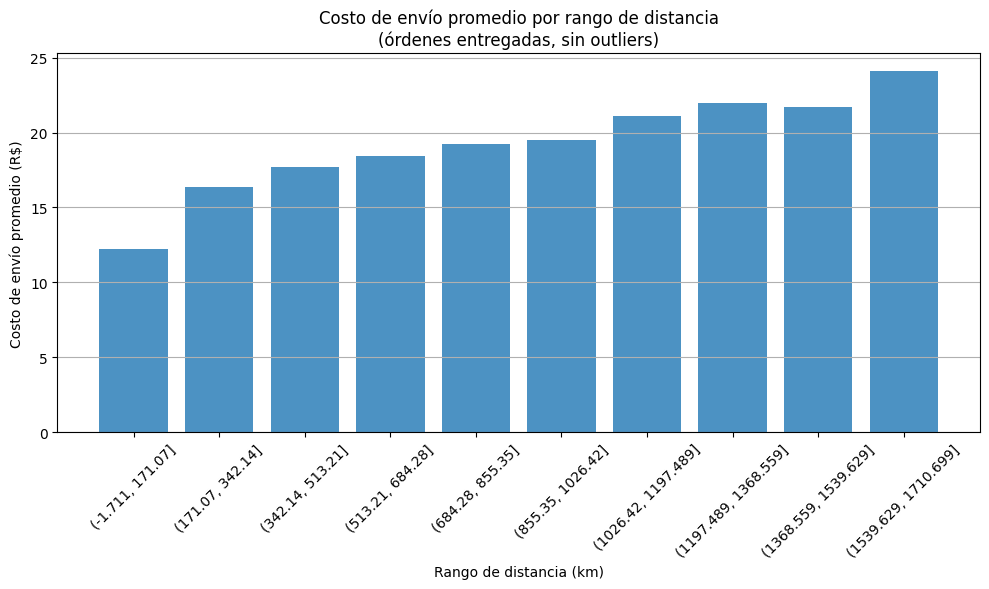

In [17]:
# 1. Filtrar pedidos entregados
delivered_df = df_merge[df_merge['ord_order_status'] == 'delivered'].copy()

# 2. Quitar outliers de distancia y costo de envío
distancia_sin_outliers = remove_outliers_iqr(delivered_df['distancia_km'].dropna())
envio_sin_outliers = remove_outliers_iqr(delivered_df['freight_value_total'].dropna())

# 3. Mantener solo pedidos válidos
filtro = delivered_df['distancia_km'].isin(distancia_sin_outliers) & \
         delivered_df['freight_value_total'].isin(envio_sin_outliers)
df_sin_outliers = delivered_df[filtro].copy()

# 4. Crear rangos de distancia
df_sin_outliers['distancia_rango'] = pd.cut(df_sin_outliers['distancia_km'], bins=10)

# 5. Calcular el costo de envío promedio por rango de distancia
grupo_distancia = df_sin_outliers.groupby('distancia_rango')['freight_value_total'].mean().reset_index()

# 6. Gráfico
plt.figure(figsize=(10, 6))
plt.bar(grupo_distancia['distancia_rango'].astype(str), grupo_distancia['freight_value_total'], alpha=0.8)
plt.xticks(rotation=45)
plt.xlabel('Rango de distancia (km)')
plt.ylabel('Costo de envío promedio (R$)')
plt.title('Costo de envío promedio por rango de distancia\n(órdenes entregadas, sin outliers)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


### Costo de envio vs peso facturable y distancia

/tmp/ipython-input-18-2563952391.py:20: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabla_calor = df_sin_outliers.pivot_table(


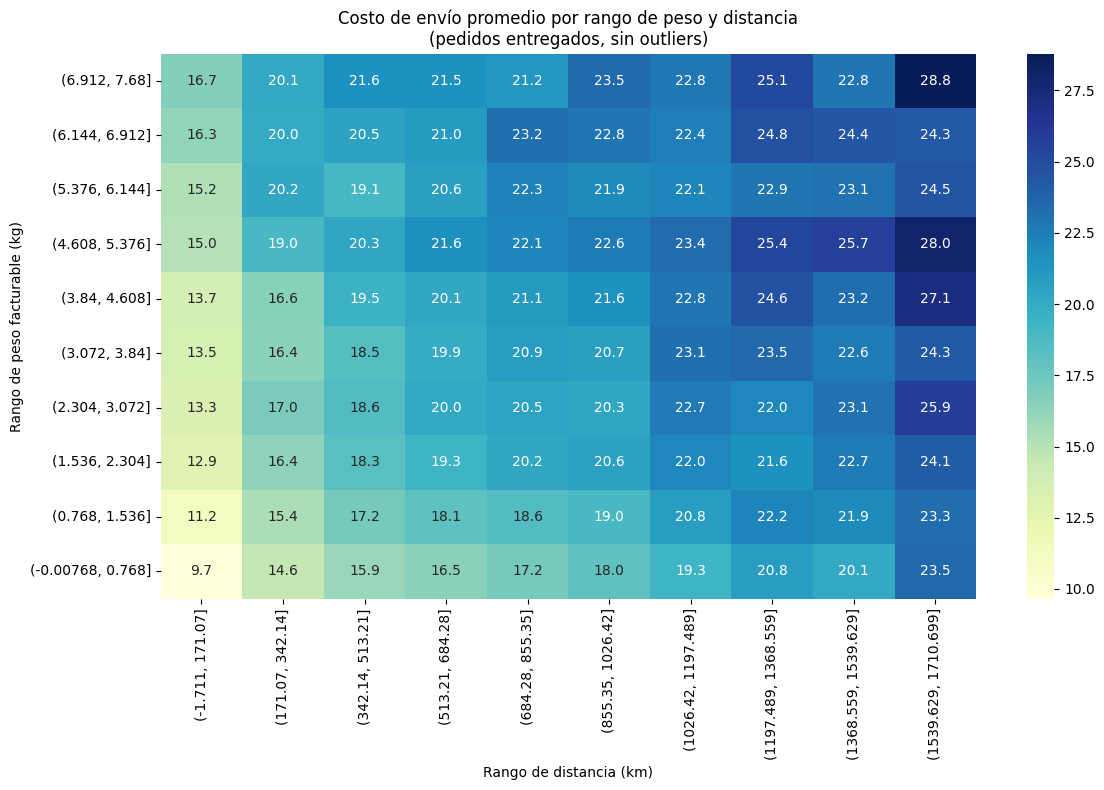

In [18]:
# 1. Filtrar pedidos entregados
delivered_df = df_merge[df_merge['ord_order_status'] == 'delivered'].copy()

# 2. Quitar outliers de peso, distancia y costo
peso_ok = remove_outliers_iqr(delivered_df['pro_peso_facturable_kg'].dropna())
dist_ok = remove_outliers_iqr(delivered_df['distancia_km'].dropna())
envio_ok = remove_outliers_iqr(delivered_df['freight_value_total'].dropna())

# 3. Filtrar el dataset
filtro = delivered_df['pro_peso_facturable_kg'].isin(peso_ok) & \
         delivered_df['distancia_km'].isin(dist_ok) & \
         delivered_df['freight_value_total'].isin(envio_ok)
df_sin_outliers = delivered_df[filtro].copy()

# 4. Crear rangos para peso y distancia
df_sin_outliers['peso_rango'] = pd.cut(df_sin_outliers['pro_peso_facturable_kg'], bins=10)
df_sin_outliers['distancia_rango'] = pd.cut(df_sin_outliers['distancia_km'], bins=10)

# 5. Crear tabla cruzada
tabla_calor = df_sin_outliers.pivot_table(
    values='freight_value_total',
    index='peso_rango',
    columns='distancia_rango',
    aggfunc='mean'
)

# 6. Ordenar rangos de peso de mayor a menor (descendente)
tabla_calor = tabla_calor.sort_index(ascending=False)

# 7. Graficar heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(tabla_calor, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Costo de envío promedio por rango de peso y distancia\n(pedidos entregados, sin outliers)')
plt.xlabel('Rango de distancia (km)')
plt.ylabel('Rango de peso facturable (kg)')
plt.tight_layout()
plt.show()



**Conclusiones**
La combinacion de distancia y peso facturable influyen en el costo de envío aumentando su costo a medida que aumentan esas variables.

El peso facturable también influye pero de forma más progresiva que la distancia.


### 3 Eficiencia logística

Para medir la eficiencia logística tenemos que considerar la siguiente fórmula:

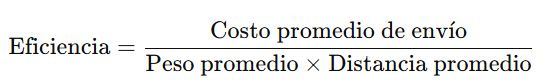

Esta métrica nos indica cuantos R$ por kg-km cuesta cada combinación de peso y distancia.  

Los valores bajos indican mayor eficiencia logística.

Los valores altos nos pueden sugerir rutas poco eficientes o costos elevados para ciertas zonas

Para saber que valor utilizar para **medir la eficiencia o ineficiencia** tenemos que considerar la distribución de _eficiencia lógistica_ (R$/kg-km)

In [19]:
# Calcular eficiencia logística
df_merge['eficiencia_logistica'] = df_merge['freight_value_total'] / (
    df_merge['pro_peso_facturable_kg'] * df_merge['distancia_km']
)

# Limpiar nulos e infinitos
df_merge.replace([np.inf, -np.inf], np.nan, inplace=True)
df_merge = df_merge.dropna(subset=['eficiencia_logistica'])

# Filtrar solo pedidos entregados
df_delivered = df_merge[df_merge['ord_order_status'] == 'delivered'].copy()

# Función para remover outliers con IQR
def remove_outliers_iqr(data, coef=1.5):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower = q1 - coef * iqr
    upper = q3 + coef * iqr
    return data[(data >= lower) & (data <= upper)]

# Aplicar filtro de outliers
eficiencia_filtrada = remove_outliers_iqr(df_delivered['eficiencia_logistica'])

# Estadísticas descriptivas de eficiencia sin outliers
eficiencia_filtrada.describe(percentiles=[0.10, .25, .5, .75, .9, .95, .99])


,eficiencia_logistica
count,86503.000000
mean,0.046085
std,0.048385
min,0.000000
10%,0.005617
25%,0.011400
50%,0.027607
75%,0.063102
90%,0.117808
95%,0.157399


### Distribución de eficiencia logística

/tmp/ipython-input-20-4088683451.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grupo = df_sin_outliers.groupby(['peso_rango', 'distancia_rango']).agg({


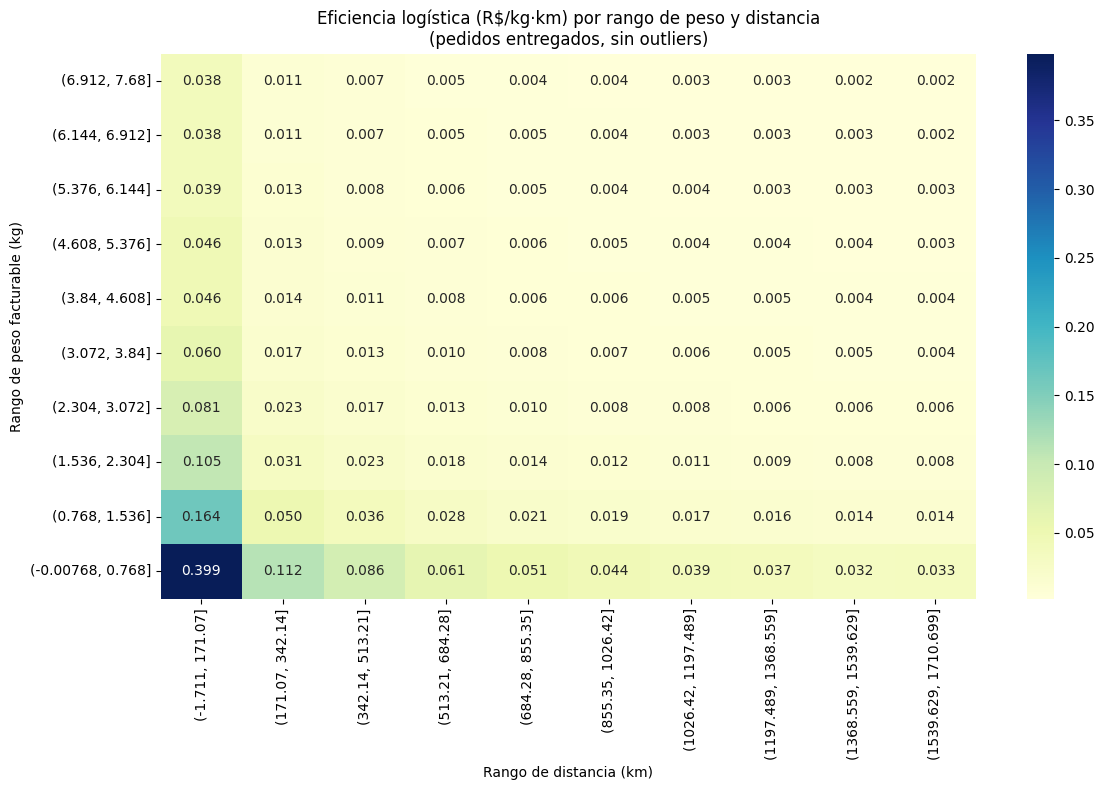

In [20]:
# Crear rangos para peso y distancia
df_sin_outliers['peso_rango'] = pd.cut(df_sin_outliers['pro_peso_facturable_kg'], bins=10)
df_sin_outliers['distancia_rango'] = pd.cut(df_sin_outliers['distancia_km'], bins=10)

# Calcular métricas por combinación de peso y distancia
grupo = df_sin_outliers.groupby(['peso_rango', 'distancia_rango']).agg({
    'freight_value_total': 'mean',
    'pro_peso_facturable_kg': 'mean',
    'distancia_km': 'mean'
}).rename(columns={
    'freight_value_total': 'costo_envio_promedio',
    'pro_peso_facturable_kg': 'peso_promedio',
    'distancia_km': 'distancia_promedio'
})

# Calcular eficiencia logística
grupo['eficiencia_r$/kg_km'] = grupo['costo_envio_promedio'] / (grupo['peso_promedio'] * grupo['distancia_promedio'])


# Crear tabla para heatmap y ordenarla en eje Y (peso) descendente
tabla_eficiencia = grupo['eficiencia_r$/kg_km'].unstack()
tabla_eficiencia_desc = tabla_eficiencia.sort_index(ascending=False)

# Graficar heatmap con eje Y ordenado descendente
plt.figure(figsize=(12, 8))
sns.heatmap(tabla_eficiencia_desc, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title('Eficiencia logística (R$/kg·km) por rango de peso y distancia\n(pedidos entregados, sin outliers)')
plt.xlabel('Rango de distancia (km)')
plt.ylabel('Rango de peso facturable (kg)')
plt.tight_layout()
plt.show()




#### Zonas y artículos con ineficiencia

Considerando los resultados obtenidos en la distribución de eficiencia logística podríamos considerar el umbral de eficiencia en torno a 0.063 que nos coloca en los valores superiores al percentil 75.  De esta forma identificaríamos a zonas ineficientes

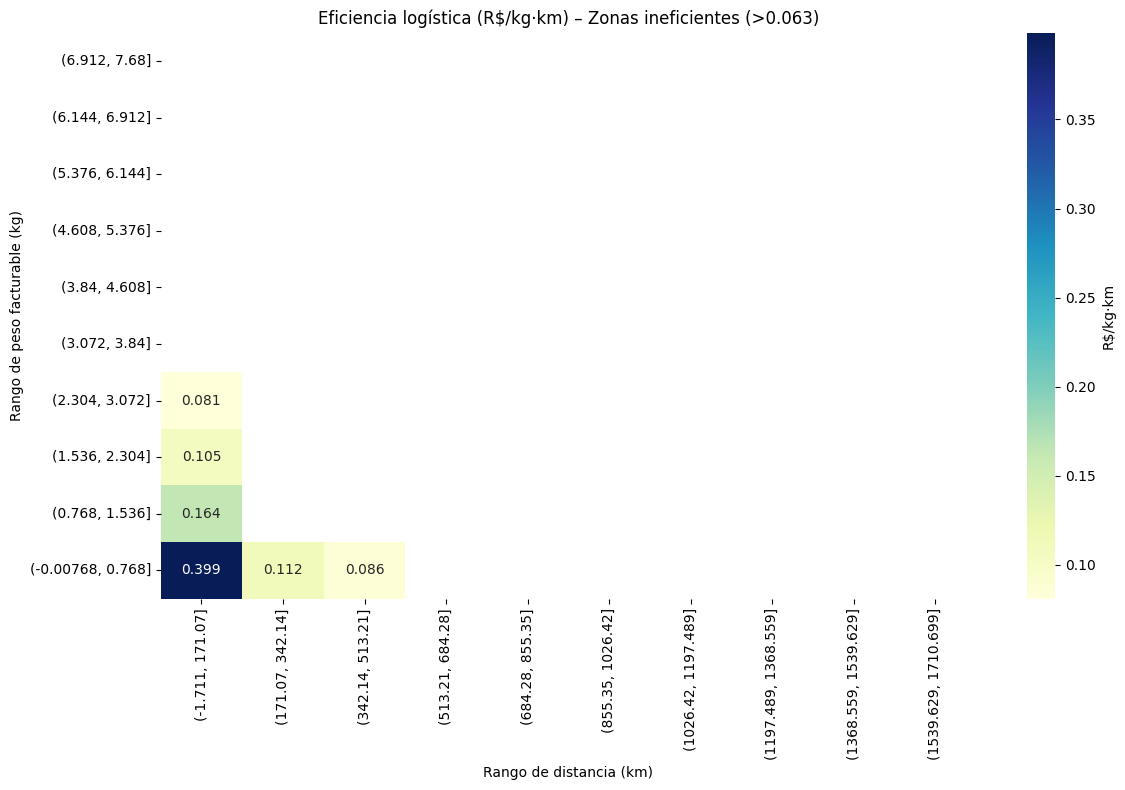

In [21]:
# definir tabla_eficiencia_con_umbral usando la tabla de eficiencia ya calculada
tabla_eficiencia_con_umbral = tabla_eficiencia.copy()

# Definición del umbral de ineficiencia
umbral_ineficiencia = 0.063  # You can adjust this value as needed

# Ordenar el índice del eje Y en forma descendente
tabla_eficiencia_con_umbral_desc = tabla_eficiencia_con_umbral.sort_index(ascending=False)

# Volver a graficar el heatmap con el eje Y descendente y zonas ineficientes destacadas
plt.figure(figsize=(12, 8))
sns.heatmap(
    tabla_eficiencia_con_umbral_desc,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    cbar_kws={'label': 'R$/kg·km'},
    mask=tabla_eficiencia_con_umbral_desc <= umbral_ineficiencia
)
plt.title(f'Eficiencia logística (R$/kg·km) – Zonas ineficientes (>{umbral_ineficiencia:.3f})')
plt.xlabel('Rango de distancia (km)')
plt.ylabel('Rango de peso facturable (kg)')
plt.tight_layout()
plt.show()

##### Listado de productos ineficientes (quartil 75)

In [23]:
# Filtrar registros entregados y sin outliers cuya eficiencia logística es mayor al umbral de ineficiencia
umbral_ineficiencia = 0.063
productos_ineficientes = df_delivered[
    (df_delivered['eficiencia_logistica'] > umbral_ineficiencia)
]

# Contar cuántos productos por categoría en inglés están incluidos
productos_por_categoria = productos_ineficientes['pro_product_category_name_english'].value_counts()

# Mostrar los resultados
productos_por_categoria.head(10)


,count
pro_product_category_name_english,
health_beauty,3778
watches_gifts,3265
telephony,3029
computers_accessories,2946
sports_leisure,2225
bed_bath_table,1855
furniture_decor,1649
housewares,1611
perfumery,1463


##### Gráfico de productos ineficientes (90%)



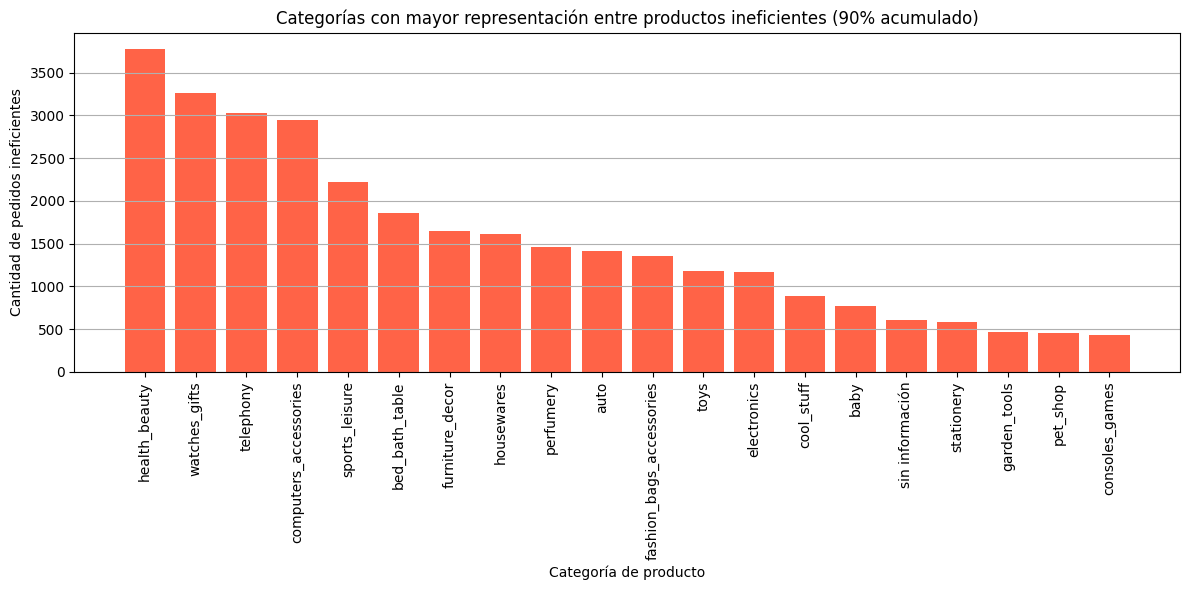

In [24]:
# Calcular el total de productos ineficientes
total_ineficientes = productos_por_categoria.sum()

# Calcular el porcentaje acumulado
productos_por_categoria_df = productos_por_categoria.reset_index()
productos_por_categoria_df.columns = ['categoria', 'cantidad']
productos_por_categoria_df['porcentaje'] = productos_por_categoria_df['cantidad'] / total_ineficientes * 100
productos_por_categoria_df['porcentaje_acumulado'] = productos_por_categoria_df['porcentaje'].cumsum()

# Filtrar las categorías que representan el 90% de la muestra
top_90_df = productos_por_categoria_df[productos_por_categoria_df['porcentaje_acumulado'] <= 90]

# Gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(top_90_df['categoria'], top_90_df['cantidad'], color='tomato')
plt.xticks(rotation=90)
plt.title('Categorías con mayor representación entre productos ineficientes (90% acumulado)')
plt.xlabel('Categoría de producto')
plt.ylabel('Cantidad de pedidos ineficientes')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


##### Grafico de productos ineficientes (80%)

Se considera el 80% de la muestra

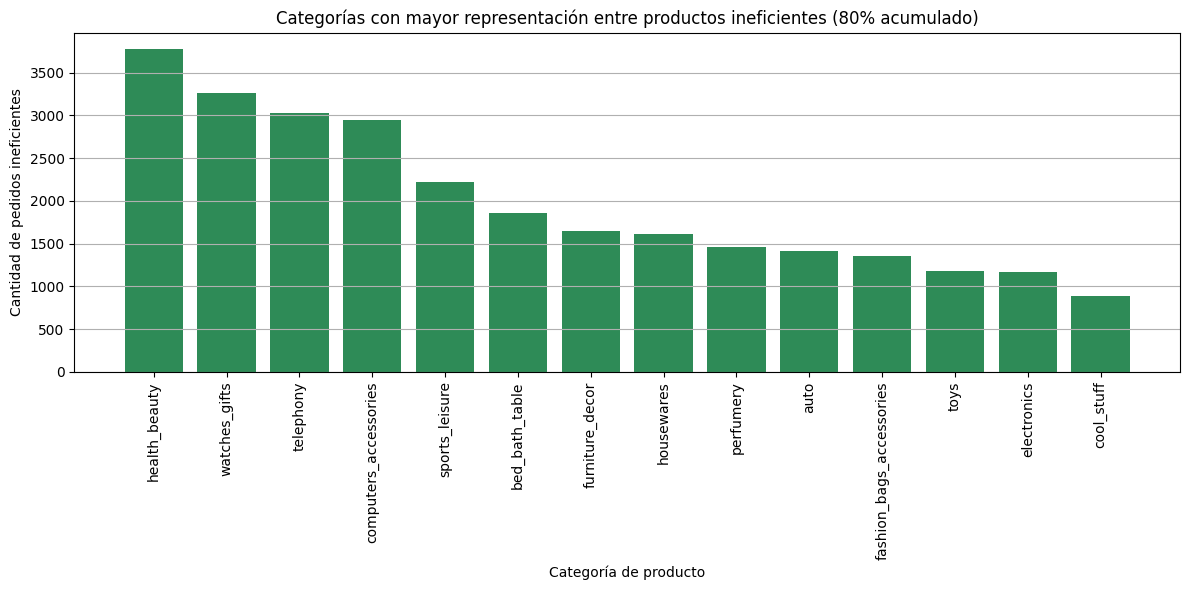

In [26]:
# Filtrar las categorías que representan el 80% de la muestra
top_80_df = productos_por_categoria_df[productos_por_categoria_df['porcentaje_acumulado'] <= 80]

# Gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(top_80_df['categoria'], top_80_df['cantidad'], color='seagreen')
plt.xticks(rotation=90)
plt.title('Categorías con mayor representación entre productos ineficientes (80% acumulado)')
plt.xlabel('Categoría de producto')
plt.ylabel('Cantidad de pedidos ineficientes')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


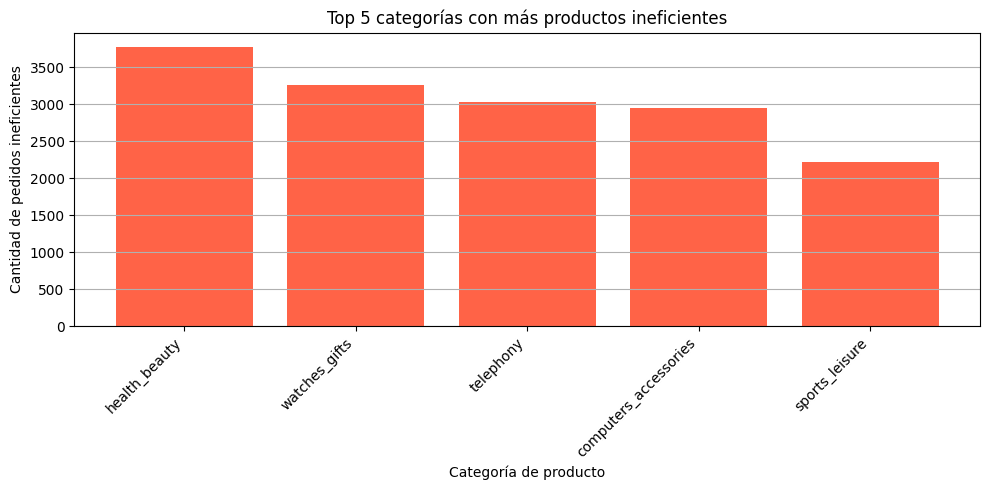

In [28]:
# Calcular el total de productos ineficientes
total_ineficientes = productos_por_categoria.sum()

# Calcular el porcentaje acumulado
productos_por_categoria_df = productos_por_categoria.reset_index()
productos_por_categoria_df.columns = ['categoria', 'cantidad']
productos_por_categoria_df['porcentaje'] = productos_por_categoria_df['cantidad'] / total_ineficientes * 100
productos_por_categoria_df['porcentaje_acumulado'] = productos_por_categoria_df['porcentaje'].cumsum()

# Seleccionar las 5 categorías con mayor cantidad de productos ineficientes
top_5_df = productos_por_categoria_df.sort_values(by='cantidad', ascending=False).head(5)

# Gráfico de barras
plt.figure(figsize=(10, 5))
plt.bar(top_5_df['categoria'], top_5_df['cantidad'], color='tomato')
plt.xticks(rotation=45, ha='right')
plt.title('Top 5 categorías con más productos ineficientes')
plt.xlabel('Categoría de producto')
plt.ylabel('Cantidad de pedidos ineficientes')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [27]:
# Seleccionar solo los registros de las categorías que representan el 80% de los ineficientes
categorias_top_80 = top_80_df['categoria'].tolist()
df_top_ineficientes = productos_ineficientes[
    productos_ineficientes['pro_product_category_name_english'].isin(categorias_top_80)
]

# Calcular promedio de peso facturable y distancia por categoría
cruce_peso_distancia = df_top_ineficientes.groupby('pro_product_category_name_english')[
    ['pro_peso_facturable_kg', 'distancia_km']
].mean().sort_values(by='pro_peso_facturable_kg', ascending=False)

cruce_peso_distancia

,pro_peso_facturable_kg,distancia_km
pro_product_category_name_english,,
furniture_decor,2.165268,175.075375
cool_stuff,2.127366,176.893044
housewares,2.077364,157.532333
bed_bath_table,1.768082,188.741991
toys,1.419128,173.481777
sports_leisure,1.232046,199.195111
auto,1.224214,265.957621
health_beauty,0.863016,227.350965
electronics,0.682976,276.096291


Lo que observamos es que algunas categorías combinan peso alto con distancia baja (ej. furniture_decor), lo que puede indicar ineficiencia por manipulación o volumen.

Otras tienen peso más ligero pero aún con distancias considerables, como toys o cool_stuff.

Lo que observamos es que estás categorías estan asociadas a productos livianos, lo que explica su aparición frecuente en combinaciones donde los costos de envío no se diluyen adecuadamente

#### Zonas y artículos con eficiencia

Considerando los resultados obtenidos en la distribución de eficiencia logística podríamos considerar el umbral de eficiencia en torno a 0.005617 que nos coloca en los valores inferiores al percentil 10.  De esta forma identificaríamos a zonas más eficientes

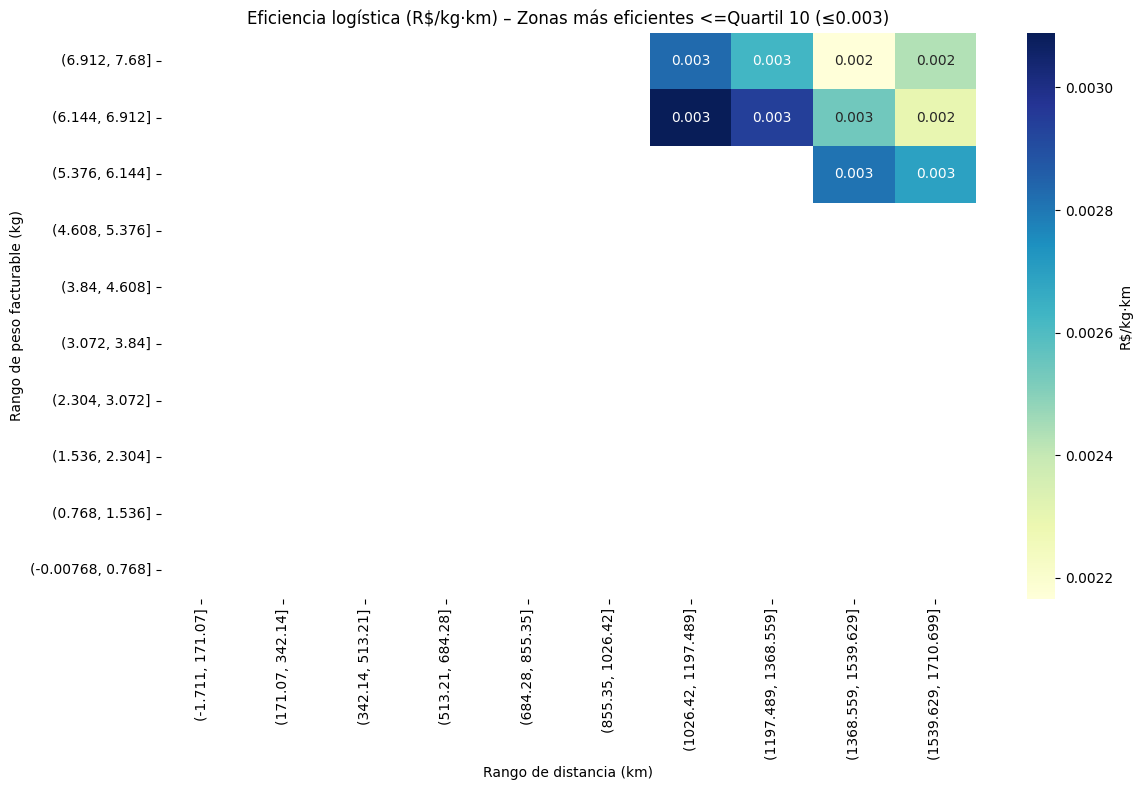

In [29]:
# Definir tabla de eficiencia si no está en memoria
tabla_eficiencia_con_umbral = tabla_eficiencia.copy()

# Calcular el umbral del percentil 10
umbral_eficiencia = grupo['eficiencia_r$/kg_km'].quantile(0.10)

# Ordenar el índice del eje Y en forma descendente
tabla_eficiencia_con_umbral_desc = tabla_eficiencia_con_umbral.sort_index(ascending=False)

# Crear el heatmap resaltando zonas más eficientes
plt.figure(figsize=(12, 8))
sns.heatmap(
    tabla_eficiencia_con_umbral_desc,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    cbar_kws={'label': 'R$/kg·km'},
    mask=tabla_eficiencia_con_umbral_desc > umbral_eficiencia  # mostrar solo zonas más eficientes
)
plt.title(f'Eficiencia logística (R$/kg·km) – Zonas más eficientes <=Quartil 10 (≤{umbral_eficiencia:.3f})')
plt.xlabel('Rango de distancia (km)')
plt.ylabel('Rango de peso facturable (kg)')
plt.tight_layout()
plt.show()

Observamos las zonas más eficientes.  Es decir, con menor costo logístico por unidad transportada.


##### Listado de productos eficientes (quartil 10)

In [30]:
# Filtrar registros entregados y sin outliers cuya eficiencia logística es mayor al umbral de eficiencia
umbral_eficiencia = 0.005617
productos_eficientes = df_delivered[
    (df_delivered['eficiencia_logistica'] < umbral_eficiencia)
]

# Contar cuántos productos por categoría en inglés están incluidos
productos_por_categoria = productos_eficientes['pro_product_category_name_english'].value_counts()

# Mostrar los resultados
productos_por_categoria.head(20)


,count
pro_product_category_name_english,
bed_bath_table,936
furniture_decor,730
housewares,635
sports_leisure,617
cool_stuff,616
garden_tools,613
baby,516
toys,481
auto,466


##### Gráfico de productos eficientes (90%)

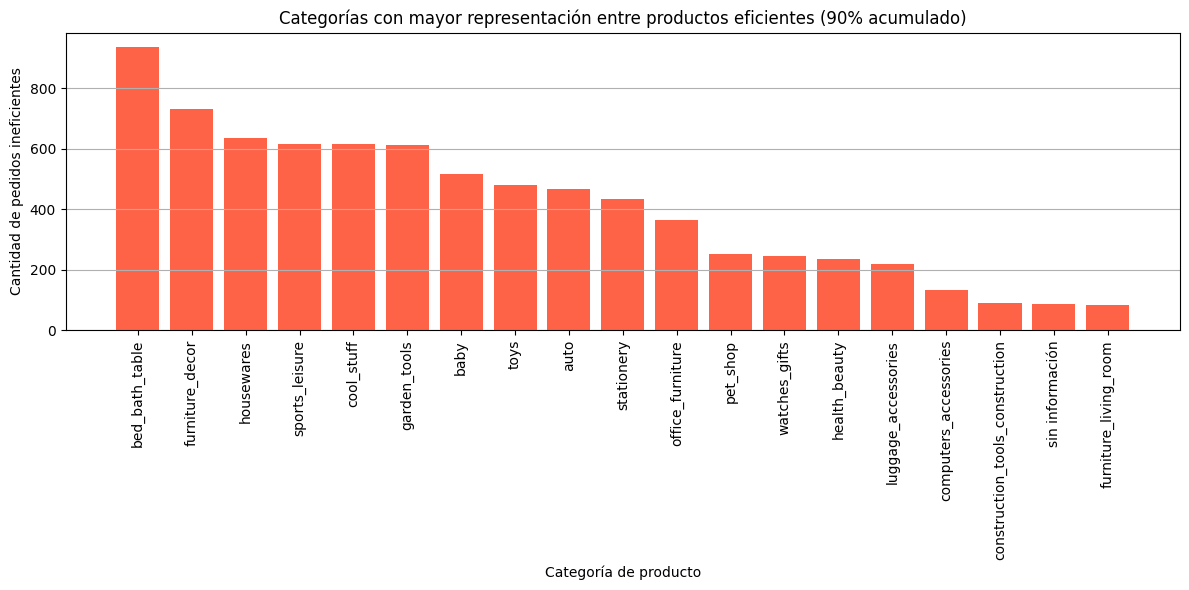

In [31]:
# Calcular el total de productos ineficientes
total_eficientes = productos_por_categoria.sum()

# Calcular el porcentaje acumulado
productos_por_categoria_df = productos_por_categoria.reset_index()
productos_por_categoria_df.columns = ['categoria', 'cantidad']
productos_por_categoria_df['porcentaje'] = productos_por_categoria_df['cantidad'] / total_eficientes * 100
productos_por_categoria_df['porcentaje_acumulado'] = productos_por_categoria_df['porcentaje'].cumsum()

# Filtrar las categorías que representan el 90% de la muestra
top_90_df = productos_por_categoria_df[productos_por_categoria_df['porcentaje_acumulado'] <= 90]

# Gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(top_90_df['categoria'], top_90_df['cantidad'], color='tomato')
plt.xticks(rotation=90)
plt.title('Categorías con mayor representación entre productos eficientes (90% acumulado)')
plt.xlabel('Categoría de producto')
plt.ylabel('Cantidad de pedidos ineficientes')
plt.grid(axis='y')
plt.tight_layout()
plt.show()



##### Gráfico de productos eficientes (80%)

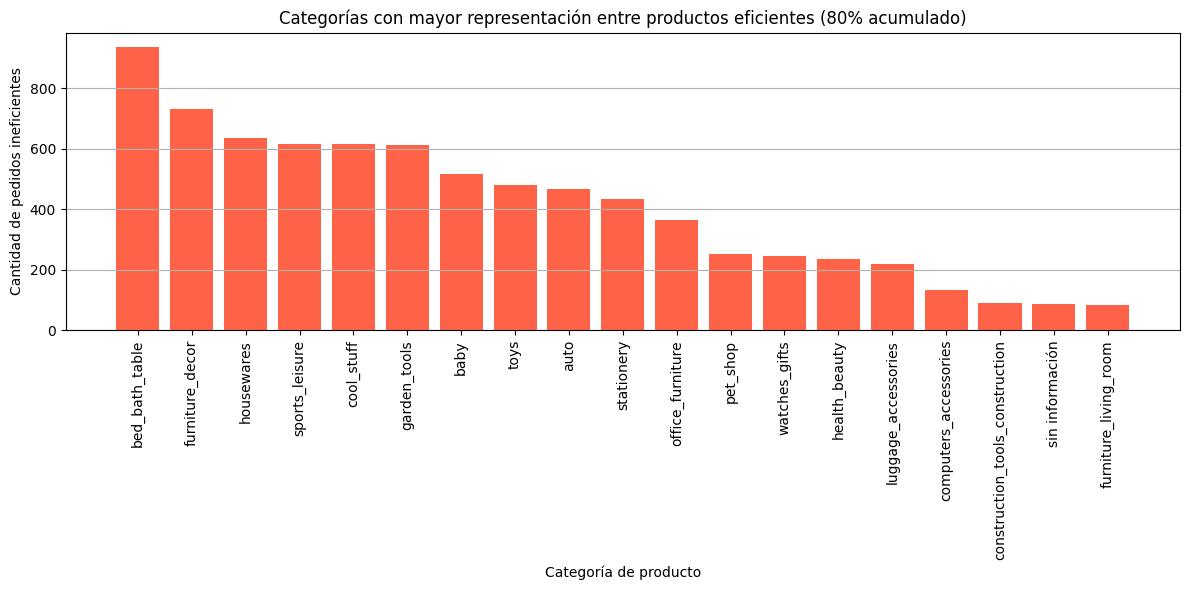

In [32]:
# Calcular el total de productos eficientes
total_eficientes = productos_por_categoria.sum()

# Calcular el porcentaje acumulado
productos_por_categoria_df = productos_por_categoria.reset_index()
productos_por_categoria_df.columns = ['categoria', 'cantidad']
productos_por_categoria_df['porcentaje'] = productos_por_categoria_df['cantidad'] / total_eficientes * 100
productos_por_categoria_df['porcentaje_acumulado'] = productos_por_categoria_df['porcentaje'].cumsum()

# Filtrar las categorías que representan el 80% de la muestra
top_80_df = productos_por_categoria_df[productos_por_categoria_df['porcentaje_acumulado'] <= 80]

# Gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(top_90_df['categoria'], top_90_df['cantidad'], color='tomato')
plt.xticks(rotation=90)
plt.title('Categorías con mayor representación entre productos eficientes (80% acumulado)')
plt.xlabel('Categoría de producto')
plt.ylabel('Cantidad de pedidos ineficientes')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


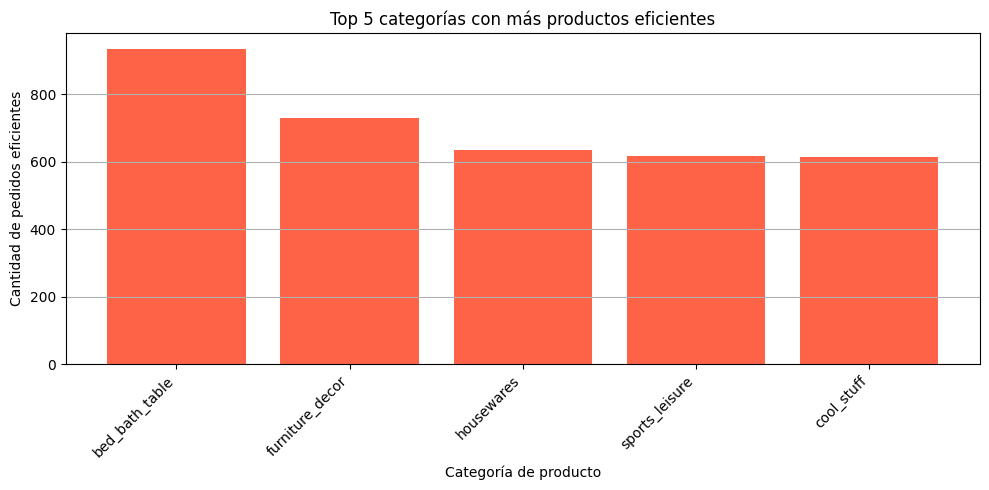

In [33]:
# Calcular el total de productos eficientes
total_eficientes = productos_por_categoria.sum()

# Calcular el porcentaje acumulado
productos_por_categoria_df = productos_por_categoria.reset_index()
productos_por_categoria_df.columns = ['categoria', 'cantidad']
productos_por_categoria_df['porcentaje'] = productos_por_categoria_df['cantidad'] / total_eficientes * 100
productos_por_categoria_df['porcentaje_acumulado'] = productos_por_categoria_df['porcentaje'].cumsum()

# Seleccionar las 5 categorías con mayor cantidad de productos eficientes
top_5_df = productos_por_categoria_df.sort_values(by='cantidad', ascending=False).head(5)

# Gráfico de barras
plt.figure(figsize=(10, 5))
plt.bar(top_5_df['categoria'], top_5_df['cantidad'], color='tomato')
plt.xticks(rotation=45, ha='right')
plt.title('Top 5 categorías con más productos eficientes')
plt.xlabel('Categoría de producto')
plt.ylabel('Cantidad de pedidos eficientes')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


# Conclusiones

1. Eficiencia estructural (producto)

 🔹Reducir el impacto de productos ineficientes
   
    Agrupar ítems livianos: Incentivar packs de productos como health_beauty o watches_gifts para evitar envíos de bajo peso individual.

    Rediseñar packaging para que el peso volumétrico se reduzca y no genere cobros excesivos por espacio.

  🔹Incentivar productos eficientes

    Destacar productos que naturalmente tienen una mejor relación peso/distancia/costo, como algunos artículos de bed_bath_table.

2. Eficiencia operativa (logística)

  🔹Optimización por zonas

    Crear un sistema de tarifas o políticas diferenciadas para zonas detectadas como ineficientes.

    Usar los rangos de peso y distancia del heatmap para ajustar los precios de envío.

  🔹Agrupación de pedidos
    
    Usar ventanas de entrega más amplias para consolidar envíos en zonas con alta ineficiencia.

3. Eficiencia comercial (pricing)

  🔹 Cobrar con base en el R$/kg·km para envíos que superen cierto umbral de ineficiencia.

  🔹Envío gratuito condicional
    Ofrecer envío gratis solo si el pedido alcanza:

    Cierto peso mínimo (para no ser ineficiente)

    O cierta combinación de productos eficientes
